In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlgrad.funcs as funcs
import mlgrad.smooth as smooth
import mlgrad.inventory as inventory

In [2]:
df = pd.read_csv("noise/noise_nm.csv", sep=";")
df

,id,x,y
0,0,804.832214,3.800000
1,1,804.886536,0.249994
2,2,804.940857,1.950006
3,3,804.995178,0.450000
4,4,805.049500,1.500006
...,...,...,...
2043,2043,915.261841,-0.000006
2044,2044,915.315552,-1.550006
2045,2045,915.369202,0.799982
2046,2046,915.422913,4.250000


0.010027971651649587 1.5367297715672046
6.10351571594947e-06 1.4819568194225043
0.004503592390418039
6.10351571594947e-06


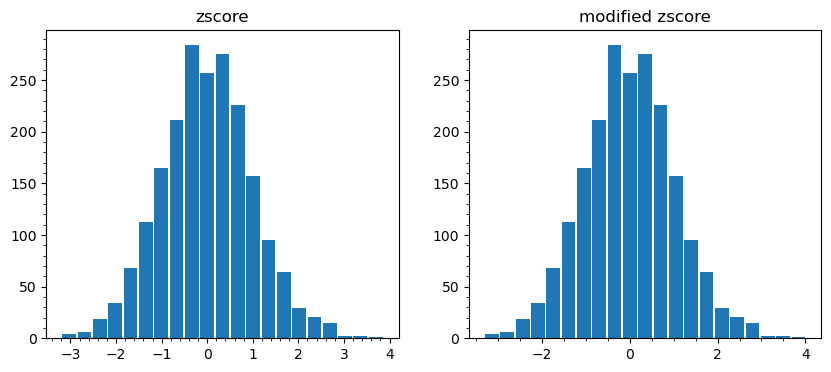

In [5]:
X, Y = df["x"].values, df["y"].values
print(Y.mean(), Y.std())
print(inventory.median_1d(Y), inventory.median_absdev_1d(Y))
print(inventory.robust_mean_1d(Y, 3.0))
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("zscore")
plt.hist(inventory.zscore(Y), bins=21, rwidth=0.9)
plt.minorticks_on()
plt.subplot(1,2,2)
plt.title("modified zscore")
plt.hist(inventory.modified_zscore(Y), bins=21, rwidth=0.9)
plt.minorticks_on()
plt.show()

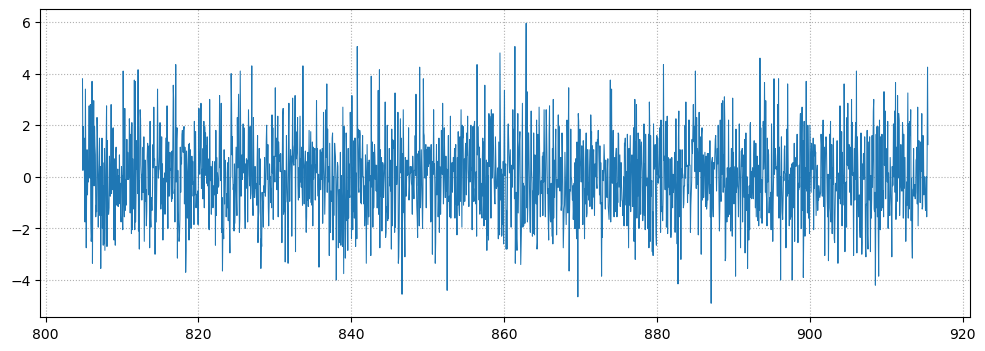

In [4]:
plt.figure(figsize=(12,4))
plt.plot(X, Y, lw=0.75)
plt.grid(ls=':')
plt.show()

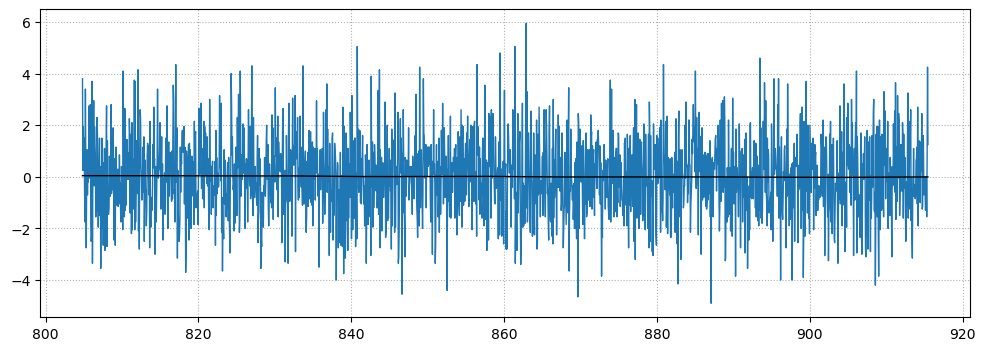

In [48]:
Y_wh = smooth.whittaker_smooth(Y, tau2=1.0e5, d=1)

plt.figure(figsize=(12,4))
plt.plot(X, Y, lw=1.0)
plt.plot(X, Y_wh, lw=1.0, color='k')
plt.grid(ls=':')
plt.show()